# DICOM CT Preprocessing Pipeline — LIDC-IDRI

**Dataset:** LIDC-IDRI — the original DICOM source that LUNA16 was derived from  
**Goal:** Build the full preprocessing pipeline that converts raw clinical DICOM CT scans  
into clean, normalised 3D volumes ready for a deep learning model.

This notebook documents real problems encountered during preprocessing and how they were solved.  
That is intentional — these issues appear in every real clinical DICOM dataset.

**Pipeline steps:**
1. Navigate the DICOM folder hierarchy
2. Read and interpret DICOM header tags
3. Sort slices by physical position
4. Stack slices into a 3D volume
5. Convert raw pixel values → Hounsfield Units
6. Resample to 1mm isotropic spacing
7. Apply HU windowing and normalise to [0, 1]

## 1. Imports

In [22]:
import pydicom          # reads DICOM files and headers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk  # resampling — same library used in LUNA16
from pathlib import Path

## 2. Dataset Structure

DICOM data always uses a 3-level hierarchy:
```
Patient/
  Study (named by scan date)/
    Series (named by series UID)/
      1-001.dcm  ← one file per axial slice
      1-002.dcm
      ...
```
The study and series folder names are auto-generated from metadata — they look like
`01-01-2000-NA-NA-30178` and cannot be predicted without opening the data first.
This is why we always use `rglob('*.dcm')` to find slices recursively,
rather than trying to construct paths manually.

In [23]:
BASE = Path("/kaggle/input/datasets/washingtongold/lidcidri30/LIDC-IDRI-0001-0200")

# Show the nested structure inside one patient folder
patient_dir = BASE / "LIDC-IDRI-0001"
print("Patient folder structure:")
for item in sorted(patient_dir.rglob("*"))[:15]:
    depth = len(item.relative_to(patient_dir).parts)
    print(f"  {'  ' * depth}{item.name}  ({'dir' if item.is_dir() else 'file'})")

# Count .dcm files recursively
all_dcm = list(patient_dir.rglob("*.dcm"))
print(f"\nTotal .dcm files (all types): {len(all_dcm)}")

Patient folder structure:
    01-01-2000-NA-NA-30178  (dir)
      3000566.000000-NA-03192  (dir)
        069.xml  (file)
        1-001.dcm  (file)
        1-002.dcm  (file)
        1-003.dcm  (file)
        1-004.dcm  (file)
        1-005.dcm  (file)
        1-006.dcm  (file)
        1-007.dcm  (file)
        1-008.dcm  (file)
        1-009.dcm  (file)
        1-010.dcm  (file)
        1-011.dcm  (file)
        1-012.dcm  (file)

Total .dcm files (all types): 135


## 3. Read One DICOM File and Inspect the Header

Every `.dcm` file contains two parts:
- **Header** — metadata tags describing the scan (patient, scanner settings, geometry)
- **Pixel data** — the actual image

The header tags we need for preprocessing:

| Tag | What it means |
|---|---|
| `PixelSpacing` | mm per pixel in x and y (in-plane resolution) |
| `SliceThickness` | mm between consecutive slices (z resolution) |
| `ImagePositionPatient` | physical position of this slice in mm — used for sorting |
| `RescaleSlope / Intercept` | converts stored integer values → Hounsfield Units |
| `Modality` | type of image (CT, MR, PR...) — important for filtering |

In [24]:
# Load first file — stop_before_pixels=True reads header only (fast)
dcm_files = sorted(patient_dir.rglob("*.dcm"))
sample    = pydicom.dcmread(str(dcm_files[0]))

print("Key DICOM header tags:")
print(f"  Patient ID:            {sample.get('PatientID', 'N/A')}")
print(f"  Modality:              {sample.get('Modality', 'N/A')}")
print(f"  Rows x Columns:        {sample.Rows} x {sample.Columns}")
print(f"  Pixel Spacing (y, x):  {sample.get('PixelSpacing', 'N/A')} mm")
print(f"  Slice Thickness:       {sample.get('SliceThickness', 'N/A')} mm")
print(f"  Image Position:        {sample.get('ImagePositionPatient', 'N/A')}")
print(f"  Rescale Slope:         {sample.get('RescaleSlope', 'N/A')}")
print(f"  Rescale Intercept:     {sample.get('RescaleIntercept', 'N/A')}")
print(f"  Raw pixel dtype:       {sample.pixel_array.dtype}")
print(f"  Raw pixel range:       [{sample.pixel_array.min()}, {sample.pixel_array.max()}]")

Key DICOM header tags:
  Patient ID:            LIDC-IDRI-0001
  Modality:              CT
  Rows x Columns:        512 x 512
  Pixel Spacing (y, x):  [0.703125, 0.703125] mm
  Slice Thickness:       2.500000 mm
  Image Position:        [-166.000000, -171.699997, -10.000000]
  Rescale Slope:         1
  Rescale Intercept:     -1024
  Raw pixel dtype:       int16
  Raw pixel range:       [-1024, 4095]


## 4. Sort Slices by Physical Position

Filenames like `1-001.dcm`, `1-002.dcm` suggest order — but this is not guaranteed.
Different scanners and PACS systems number slices inconsistently.

The correct method is to sort by the `ImagePositionPatient` tag, which records
the exact physical z-position of each slice in millimetres.

### Problem encountered
The first attempt failed because 2 out of 135 slices were missing the `ImagePositionPatient` tag,
causing an `AttributeError`. Real DICOM data is inconsistent — not every file has every tag.

### Fix
Use a fallback chain: try `ImagePositionPatient` first, then `SliceLocation`,
then `InstanceNumber`. Track which tag was used for each slice.

In [25]:
def get_z_position(dcm_path):
    """Get z-position with fallback tags for missing ImagePositionPatient."""
    ds = pydicom.dcmread(str(dcm_path), stop_before_pixels=True)
    if hasattr(ds, "ImagePositionPatient"):
        return float(ds.ImagePositionPatient[2])
    elif hasattr(ds, "SliceLocation"):
        return float(ds.SliceLocation)
    elif hasattr(ds, "InstanceNumber"):
        return float(ds.InstanceNumber)
    else:
        return 0.0


dcm_files_sorted = sorted(dcm_files, key=get_z_position)

# Check which tag was used across all slices
tag_counts = {"ImagePositionPatient": 0, "SliceLocation": 0, "InstanceNumber": 0, "none": 0}
for f in dcm_files_sorted:
    ds = pydicom.dcmread(str(f), stop_before_pixels=True)
    if hasattr(ds, "ImagePositionPatient"):   tag_counts["ImagePositionPatient"] += 1
    elif hasattr(ds, "SliceLocation"):        tag_counts["SliceLocation"] += 1
    elif hasattr(ds, "InstanceNumber"):       tag_counts["InstanceNumber"] += 1
    else:                                     tag_counts["none"] += 1

print("Sorting tag used per slice:")
for tag, count in tag_counts.items():
    if count > 0:
        print(f"  {tag}: {count} slices")

z_positions = [get_z_position(f) for f in dcm_files_sorted]
print(f"\nFirst 5 z: {[round(z, 2) for z in z_positions[:5]]}")
print(f"Last  5 z: {[round(z, 2) for z in z_positions[-5:]]}")

Sorting tag used per slice:
  ImagePositionPatient: 133 slices
  InstanceNumber: 2 slices

First 5 z: [-340.0, -337.5, -335.0, -332.5, -330.0]
Last  5 z: [-15.0, -12.5, -10.0, 1.0, 2.0]


## 5. Drop Slices With Missing Position Tag

The 2 slices that fell back to `InstanceNumber` are mispositioned in the sorted list.
Their 'z-values' are slice indices (1, 2) — not millimetres — so they land at the wrong
position in the volume. Keeping them would corrupt the 3D geometry.

Removing 2 out of 135 slices has no practical impact on the volume.

In [26]:
def has_image_position(dcm_path):
    ds = pydicom.dcmread(str(dcm_path), stop_before_pixels=True)
    return hasattr(ds, "ImagePositionPatient")

dcm_files_sorted = [f for f in dcm_files_sorted if has_image_position(f)]
z_positions      = [get_z_position(f) for f in dcm_files_sorted]

print(f"Slices after filtering: {len(dcm_files_sorted)}")
print(f"Z range: {z_positions[0]:.1f} → {z_positions[-1]:.1f} mm")
print(f"Z step (should be uniform): {z_positions[1] - z_positions[0]:.2f} mm")

Slices after filtering: 133
Z range: -340.0 → -10.0 mm
Z step (should be uniform): 2.50 mm


## 6. Build 3D Volume and Convert to Hounsfield Units

Stack all sorted slices into one 3D numpy array, then convert raw pixel values
to Hounsfield Units (HU) — the physically meaningful, scanner-independent scale.

**Conversion formula:** `HU = raw_pixel × RescaleSlope + RescaleIntercept`

For this scanner: Slope=1, Intercept=-1024, so `HU = pixel - 1024`

**HU reference values:**

| Tissue | HU |
|---|---|
| Air | -1000 |
| Lung parenchyma | -600 |
| Fat | -100 |
| Water | 0 |
| Soft tissue | +40 |
| Bone | +700 |

Without this conversion, pixel values are arbitrary scanner integers.
After conversion, -1000 means air on every scanner ever made.

In [27]:
slices     = [pydicom.dcmread(str(f)).pixel_array for f in dcm_files_sorted]
raw_volume = np.stack(slices, axis=0).astype(np.float32)   # (z, y, x)

slope     = float(sample.RescaleSlope)
intercept = float(sample.RescaleIntercept)
hu_volume = raw_volume * slope + intercept

print(f"Volume shape:     {hu_volume.shape}  (z, y, x)")
print(f"Raw pixel range:  [{raw_volume.min():.0f}, {raw_volume.max():.0f}]")
print(f"HU range:         [{hu_volume.min():.0f}, {hu_volume.max():.0f}]")
print(f"Conversion:       HU = pixel x {slope} + ({intercept})")

Volume shape:     (133, 512, 512)  (z, y, x)
Raw pixel range:  [-1024, 4095]
HU range:         [-2048, 3071]
Conversion:       HU = pixel x 1.0 + (-1024.0)


## 7. Visualise the Volume

Display top, middle, and bottom axial slices with the lung window applied.
Lung window: `vmin=-1000` (air=black), `vmax=400` (soft tissue=white).
Bone (>400 HU) clips to white — it's not relevant for lung nodule work.

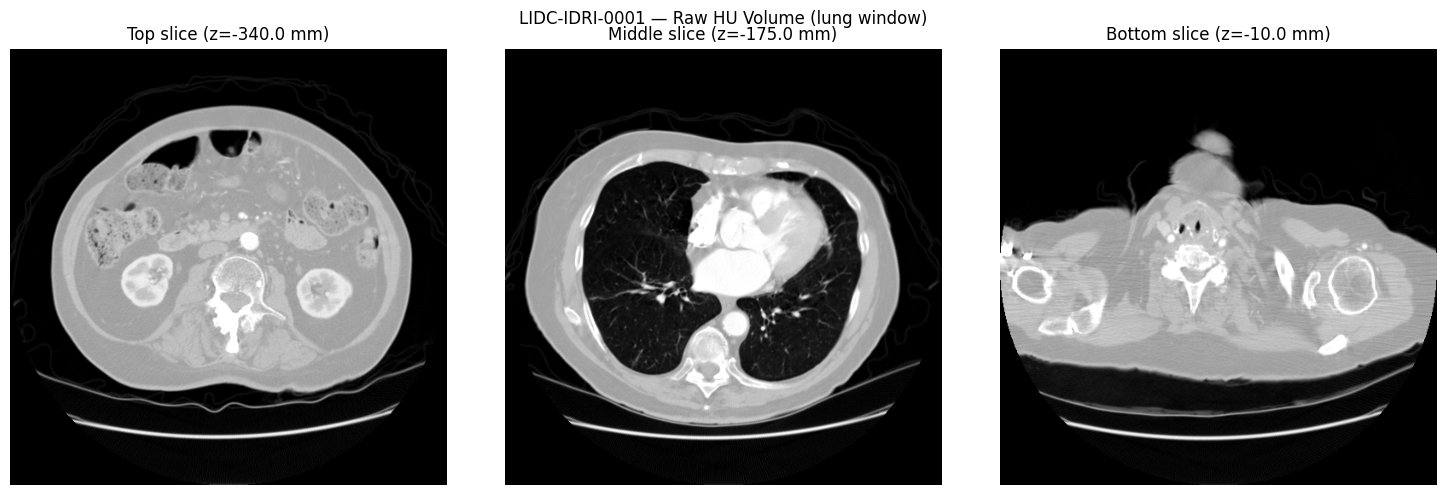

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
positions = [0, len(hu_volume)//2, len(hu_volume)-1]
titles    = ["Top slice", "Middle slice", "Bottom slice"]

for ax, idx, title in zip(axes, positions, titles):
    ax.imshow(hu_volume[idx], cmap="gray", vmin=-1000, vmax=400)
    ax.set_title(f"{title} (z={z_positions[idx]:.1f} mm)")
    ax.axis("off")

plt.suptitle("LIDC-IDRI-0001 — Raw HU Volume (lung window)", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Resample to 1mm Isotropic Spacing

**Why resampling is necessary:**

This scan has spacing: x=0.703mm, y=0.703mm, z=2.500mm — the voxels are not cubes.
A 5mm nodule would appear as ~7 pixels in x/y but only ~2 pixels in z.
The model would see a distorted shape that depends on the viewing direction.

Resampling to 1×1×1mm makes every voxel a 1mm cube. The same 5mm nodule
becomes 5 pixels in every direction on every scanner. This is exactly what
LUNA16 did when it converted these LIDC-IDRI DICOM files to MHD format.

**Effect on volume shape:**  
z: 133 slices × 2.5mm ÷ 1.0mm = 332 slices  
x/y: 512 pixels × 0.703mm ÷ 1.0mm = 360 pixels

In [29]:
def resample_to_isotropic(hu_volume, current_spacing, new_spacing=1.0):
    """
    hu_volume       : numpy array (z, y, x)
    current_spacing : [z_mm, y_mm, x_mm]
    new_spacing     : target voxel size in mm
    """
    # SimpleITK uses (x, y, z) order — opposite of numpy's (z, y, x)
    sitk_image = sitk.GetImageFromArray(hu_volume)
    sitk_image.SetSpacing([current_spacing[2],
                           current_spacing[1],
                           current_spacing[0]])

    orig_size    = sitk_image.GetSize()
    orig_spacing = sitk_image.GetSpacing()
    new_size = [
        int(round(orig_size[i] * orig_spacing[i] / new_spacing))
        for i in range(3)
    ]

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing([new_spacing, new_spacing, new_spacing])
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(sitk_image.GetDirection())
    resampler.SetOutputOrigin(sitk_image.GetOrigin())
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(-1000)  # fill new voxels with air

    resampled = resampler.Execute(sitk_image)
    return sitk.GetArrayFromImage(resampled)  # back to numpy (z, y, x)


pixel_spacing   = [float(x) for x in sample.PixelSpacing]
slice_thick     = float(sample.SliceThickness)
current_spacing = [slice_thick, pixel_spacing[0], pixel_spacing[1]]

print(f"Spacing before: z={current_spacing[0]}mm  y={current_spacing[1]}mm  x={current_spacing[2]}mm")
print(f"Shape before:   {hu_volume.shape}")

resampled_volume = resample_to_isotropic(hu_volume, current_spacing)

print(f"\nSpacing after:  1.0mm x 1.0mm x 1.0mm (isotropic)")
print(f"Shape after:    {resampled_volume.shape}")

Spacing before: z=2.5mm  y=0.703125mm  x=0.703125mm
Shape before:   (133, 512, 512)

Spacing after:  1.0mm x 1.0mm x 1.0mm (isotropic)
Shape after:    (332, 360, 360)


## 9. HU Windowing and Normalisation

Raw HU values span roughly -2048 to 3071 in this scan.
For lung nodule work, only the range [-1000, 400] matters:
- Below -1000: scanner background, outside the patient body
- Above +400: bone and metal — irrelevant for soft tissue nodule detection

Clipping removes those irrelevant extremes, then we scale to [0, 1] so the
values match what a pretrained neural network expects as input.

This is identical to the windowing step in the LUNA16 patch extraction pipeline.

In [30]:
HU_MIN, HU_MAX = -1000, 400

windowed = np.clip(resampled_volume, HU_MIN, HU_MAX)
windowed = (windowed - HU_MIN) / (HU_MAX - HU_MIN)

print(f"Shape:  {windowed.shape}")
print(f"Min:    {windowed.min():.3f}  (was {HU_MIN} HU)")
print(f"Max:    {windowed.max():.3f}  (was {HU_MAX} HU)")
print(f"Mean:   {windowed.mean():.3f}")

Shape:  (332, 360, 360)
Min:    0.000  (was -1000 HU)
Max:    1.000  (was 400 HU)
Mean:   0.282


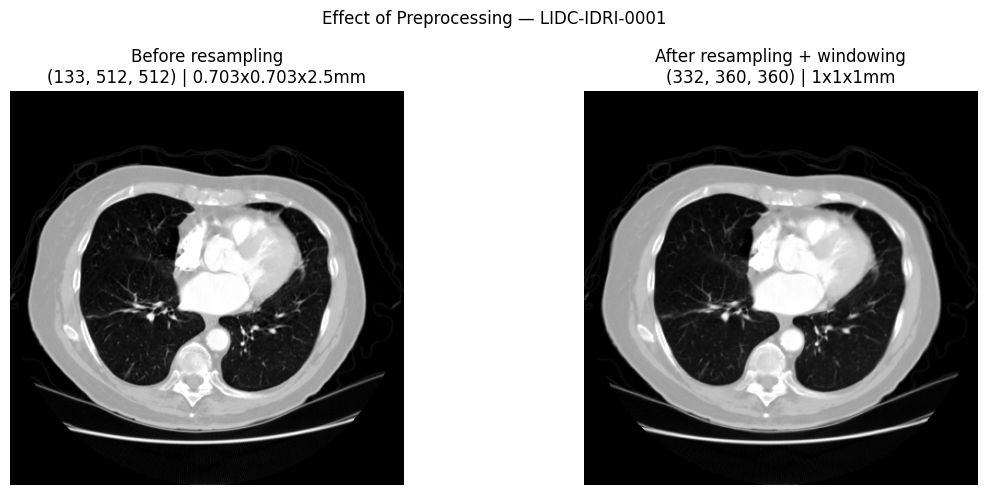

In [31]:
# Compare before and after preprocessing side by side
mid_before = hu_volume.shape[0] // 2
mid_after  = windowed.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(hu_volume[mid_before], cmap="gray", vmin=-1000, vmax=400)
axes[0].set_title(f"Before resampling\n{hu_volume.shape} | 0.703x0.703x2.5mm")
axes[0].axis("off")

axes[1].imshow(windowed[mid_after], cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"After resampling + windowing\n{windowed.shape} | 1x1x1mm")
axes[1].axis("off")

plt.suptitle("Effect of Preprocessing — LIDC-IDRI-0001", fontsize=12)
plt.tight_layout()
plt.show()

## 10. Batch Metadata Extraction

### Problem encountered
The first attempt at reading metadata across patients returned clearly wrong values —
slice thickness of -1.0mm, pixel spacing of 0.0mm, and unusual dimensions like 2007×1721.

**Cause:** LIDC-IDRI patient folders contain not just CT image slices but also
other DICOM file types — annotation objects, structured reports, presentation states.
All have a `.dcm` extension, so `rglob('*.dcm')` catches everything.
The first file found happened to be a non-image file with no spacing metadata.

### Fix
Check the `Modality` tag before reading any other metadata.
Only files with `Modality == 'CT'` are actual CT image slices.
This filter should be applied in every DICOM project.

In [32]:
def get_ct_slices_only(patient_dir):
    """Return only .dcm files that are CT image slices (Modality == 'CT')."""
    ct_files = []
    for f in sorted(patient_dir.rglob("*.dcm")):
        ds = pydicom.dcmread(str(f), stop_before_pixels=True)
        if getattr(ds, "Modality", "") == "CT":
            ct_files.append(f)
    return ct_files


def get_patient_dirs(base_dir, n=10):
    return sorted(base_dir.glob("LIDC-IDRI-*"))[:n]


def extract_patient_metadata(patient_dir):
    ct_files = get_ct_slices_only(patient_dir)
    if not ct_files:
        return None
    ds = pydicom.dcmread(str(ct_files[0]), stop_before_pixels=True)
    return {
        "patient_id"      : patient_dir.name,
        "n_slices"        : len(ct_files),
        "slice_thickness" : float(getattr(ds, "SliceThickness", -1)),
        "pixel_spacing_x" : float(getattr(ds, "PixelSpacing", [0, 0])[1]),
        "pixel_spacing_y" : float(getattr(ds, "PixelSpacing", [0, 0])[0]),
        "rows"            : int(getattr(ds, "Rows", -1)),
        "cols"            : int(getattr(ds, "Columns", -1)),
    }


patients = get_patient_dirs(BASE, n=10)
records  = []
for p in patients:
    meta = extract_patient_metadata(p)
    if meta:
        records.append(meta)
        print(f"{meta['patient_id']} | slices={meta['n_slices']} | "
              f"z={meta['slice_thickness']}mm | "
              f"xy={meta['pixel_spacing_x']:.3f}mm | "
              f"{meta['rows']}x{meta['cols']}")

df_meta = pd.DataFrame(records)
print(f"\nSlice thickness range: {df_meta['slice_thickness'].min()} - {df_meta['slice_thickness'].max()} mm")
print(f"Pixel spacing range:   {df_meta['pixel_spacing_x'].min():.3f} - {df_meta['pixel_spacing_x'].max():.3f} mm")
print(f"Slice count range:     {df_meta['n_slices'].min()} - {df_meta['n_slices'].max()}")

LIDC-IDRI-0001 | slices=133 | z=2.5mm | xy=0.703mm | 512x512
LIDC-IDRI-0002 | slices=261 | z=1.25mm | xy=0.682mm | 512x512
LIDC-IDRI-0003 | slices=140 | z=2.5mm | xy=0.820mm | 512x512
LIDC-IDRI-0004 | slices=241 | z=1.25mm | xy=0.822mm | 512x512
LIDC-IDRI-0005 | slices=133 | z=2.5mm | xy=0.664mm | 512x512
LIDC-IDRI-0006 | slices=133 | z=2.5mm | xy=0.625mm | 512x512
LIDC-IDRI-0007 | slices=145 | z=2.5mm | xy=0.781mm | 512x512
LIDC-IDRI-0008 | slices=133 | z=2.5mm | xy=0.781mm | 512x512
LIDC-IDRI-0009 | slices=256 | z=1.25mm | xy=0.781mm | 512x512
LIDC-IDRI-0010 | slices=277 | z=1.25mm | xy=0.879mm | 512x512

Slice thickness range: 1.25 - 2.5 mm
Pixel spacing range:   0.625 - 0.879 mm
Slice count range:     133 - 277


## 11. Spacing Variability Across Patients

This plot makes the case for resampling visually.
Every patient was scanned with different settings — two distinct protocols appear:
1.25mm and 2.5mm slice thickness. Pixel spacing varies from 0.625mm to 0.879mm.

Without resampling, the same 5mm nodule would be a different number of pixels
in every single scan. A model trained on this variability would need to learn
geometry correction alongside nodule detection. Resampling removes that problem entirely.

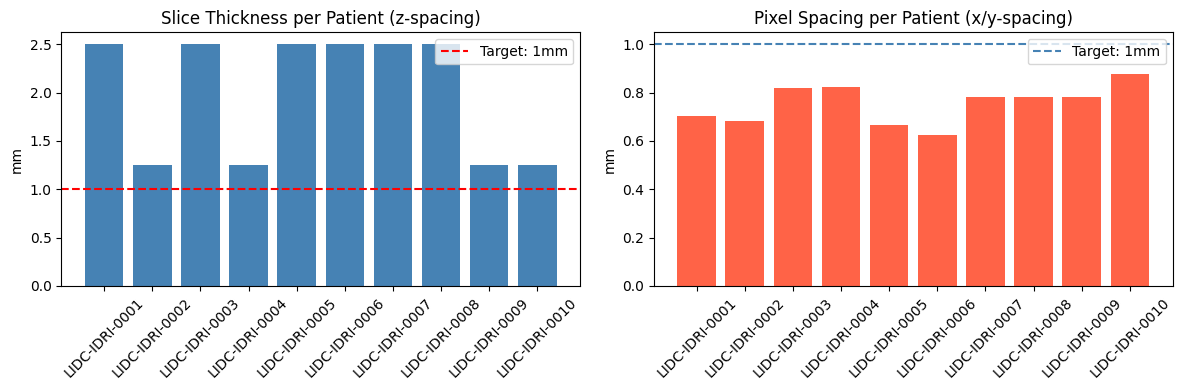

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(df_meta["patient_id"], df_meta["slice_thickness"], color="steelblue")
axes[0].set_title("Slice Thickness per Patient (z-spacing)")
axes[0].set_ylabel("mm")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(1.0, color="red", linestyle="--", label="Target: 1mm")
axes[0].legend()

axes[1].bar(df_meta["patient_id"], df_meta["pixel_spacing_x"], color="tomato")
axes[1].set_title("Pixel Spacing per Patient (x/y-spacing)")
axes[1].set_ylabel("mm")
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(1.0, color="steelblue", linestyle="--", label="Target: 1mm")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Save the Preprocessed Volume

Two output formats:

**NumPy `.npy`** — simple, fast, Python-only. Used in the LUNA16 pipeline for patch storage.

**MHD/RAW (MetaImage)** — preserves spacing and origin metadata alongside the pixel data.
This is exactly the format LUNA16 uses. When you load a LUNA16 `.mhd` file with SimpleITK,
you are loading the result of this same preprocessing pipeline applied to these same scans.

In [34]:
OUTPUT_DIR = Path("/kaggle/working/preprocessed")
OUTPUT_DIR.mkdir(exist_ok=True)

# NumPy format
np.save(OUTPUT_DIR / "LIDC-IDRI-0001_windowed.npy", windowed.astype(np.float32))
print(f"Saved .npy  — shape: {windowed.shape} | dtype: float32")

# MHD format — same as LUNA16
sitk_out = sitk.GetImageFromArray(windowed.astype(np.float32))
sitk_out.SetSpacing([1.0, 1.0, 1.0])
sitk.WriteImage(sitk_out, str(OUTPUT_DIR / "LIDC-IDRI-0001_windowed.mhd"))
print(f"Saved .mhd  — same format as LUNA16 subset files")

# Verify round-trip
reloaded = sitk.GetArrayFromImage(sitk.ReadImage(str(OUTPUT_DIR / "LIDC-IDRI-0001_windowed.mhd")))
print(f"\nRound-trip check — shapes match: {reloaded.shape == windowed.shape}")
print(f"Round-trip check — values match:  {np.allclose(reloaded, windowed)}")

Saved .npy  — shape: (332, 360, 360) | dtype: float32
Saved .mhd  — same format as LUNA16 subset files

Round-trip check — shapes match: True
Round-trip check — values match:  True


## 13. Full Pipeline as a Single Function

All steps combined into one reusable function.
This is the production-ready version — all the fixes from the notebook are baked in:
- CT-only filter (Modality == 'CT')
- Fallback sort tags (ImagePositionPatient → SliceLocation → InstanceNumber)
- Drop slices missing ImagePositionPatient
- HU conversion with slope and intercept from the header
- Isotropic resampling
- HU windowing and [0, 1] normalisation

In [35]:
def preprocess_patient(patient_dir, new_spacing=1.0, hu_min=-1000, hu_max=400):
    # Step 1 — CT slices only
    ct_files = get_ct_slices_only(patient_dir)
    if not ct_files:
        raise ValueError(f"No CT slices found in {patient_dir}")

    # Step 2 — sort by z-position, drop slices missing ImagePositionPatient
    ct_files = [f for f in ct_files if has_image_position(f)]
    ct_files = sorted(ct_files, key=get_z_position)

    # Step 3 — read spacing from header
    ds            = pydicom.dcmread(str(ct_files[0]), stop_before_pixels=True)
    slice_thick   = float(getattr(ds, "SliceThickness", 1.0))
    pixel_spacing = [float(x) for x in getattr(ds, "PixelSpacing", [1.0, 1.0])]
    slope         = float(getattr(ds, "RescaleSlope", 1.0))
    intercept     = float(getattr(ds, "RescaleIntercept", -1024.0))

    # Step 4 — stack slices
    slices     = [pydicom.dcmread(str(f)).pixel_array for f in ct_files]
    raw_volume = np.stack(slices, axis=0).astype(np.float32)

    # Step 5 — convert to HU
    hu_volume = raw_volume * slope + intercept

    # Step 6 — resample to isotropic
    current_spacing = [slice_thick, pixel_spacing[0], pixel_spacing[1]]
    resampled       = resample_to_isotropic(hu_volume, current_spacing, new_spacing)

    # Step 7 — window and normalise
    windowed = np.clip(resampled, hu_min, hu_max)
    windowed = (windowed - hu_min) / (hu_max - hu_min)

    return windowed, {
        "patient"          : patient_dir.name,
        "ct_slices"        : len(ct_files),
        "spacing_original" : current_spacing,
        "shape_before"     : hu_volume.shape,
        "shape_after"      : windowed.shape,
    }


# Test on two patients with different slice thicknesses
for patient_name in ["LIDC-IDRI-0001", "LIDC-IDRI-0008"]:
    volume, info = preprocess_patient(BASE / patient_name)
    print(f"{info['patient']}")
    print(f"  Spacing original : {info['spacing_original']}")
    print(f"  Shape before     : {info['shape_before']}")
    print(f"  Shape after      : {info['shape_after']}")
    print(f"  Value range      : [{volume.min():.2f}, {volume.max():.2f}]")
    print()

LIDC-IDRI-0001
  Spacing original : [2.5, 0.703125, 0.703125]
  Shape before     : (133, 512, 512)
  Shape after      : (332, 360, 360)
  Value range      : [0.00, 1.00]

LIDC-IDRI-0008
  Spacing original : [2.5, 0.78125, 0.78125]
  Shape before     : (133, 512, 512)
  Shape after      : (332, 400, 400)
  Value range      : [0.00, 1.00]

